In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")
sns.set_palette("colorblind")


available_metrics = {
    "duration": "Benchmark Duration (s)",
    # "completed": "Completed Requests",
    # "request_throughput": "Request Throughput (req/s)",
    # "input_throughput": "Input Throughput (tokens/s)",
    # "output_throughput": "Output Throughput (tokens/s)",
    "mean_ttft_ms": "Mean TTFT (ms)",
    "median_ttft_ms": "Median TTFT (ms)",
    # "std_ttft_ms": "Std Dev TTFT (ms)",
    "p99_ttft_ms": "P99 TTFT (ms)",
    "mean_tpot_ms": "Mean TPOT (ms)",
    "median_tpot_ms": "Median TPOT (ms)",
    # "std_tpot_ms": "Std Dev TPOT (ms)",
    "p99_tpot_ms": "P99 TPOT (ms)",
    # "mean_itl_ms": "Mean ITL (ms)",
    # "median_itl_ms": "Median ITL (ms)",
    # "std_itl_ms": "Std Dev ITL (ms)",
    # "p99_itl_ms": "P99 ITL (ms)",
    # "mean_e2e_latency_ms": "Mean E2E Latency (ms)",
    # "median_e2e_latency_ms": "Median E2E Latency (ms)",
}

In [13]:
# Function to create a bar chart for a specific metric
def plot_metric_by_strategy(file_name, metric):
    df = pd.read_csv(file_name)
    df = df[df['gpu_type'] != 'gpu_type']
    df[metric] = pd.to_numeric(df[metric], errors='raise')
    
    # Create a wider figure
    plt.figure(figsize=(8, 5))
    
    # Wrap long benchmark labels
    df['benchmark_label'] = df['benchmark_label'].str.replace("_", " ")
    df['wrapped_label'] = df['benchmark_label'].apply(lambda x: '\n'.join(wrap(x, 20)))
    
    # Define the order of strategies
    strategy_order = ['random', 'round_robin', 'pow_of_2', 'prefix_aware']
    
    # Create the grouped bar chart with specified order
    ax = sns.barplot(x='wrapped_label', y=metric, hue='scheduler_strategy', 
                     hue_order=strategy_order, data=df)
    
    # Add value labels on top of each bar
    for i, p in enumerate(ax.patches):
        value = p.get_height()
        text = f"{value:.1f}"
        ax.annotate(text, (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom')
    
    # Customize the plot
    plt.title(f"{available_metrics[metric]} by Routing Strategy")
    plt.xlabel('Benchmark Label')
    plt.ylabel(available_metrics[metric])
    
    # Improve legend labels
    strategy_labels = {
        'random': 'Random',
        'round_robin': 'Round Robin',
        'pow_of_2': 'Power of 2',
        'prefix_aware': 'Prefix Aware',
    }
    handles, labels = ax.get_legend_handles_labels()
    # Place legend to the right of the plot
    ax.legend(handles, [strategy_labels[label] for label in labels], 
              title="Routing Strategy", 
              bbox_to_anchor=(1.05, 1), 
              loc='upper left')
    
    # Adjust layout to make sure everything fits
    plt.tight_layout()
    plt.show()

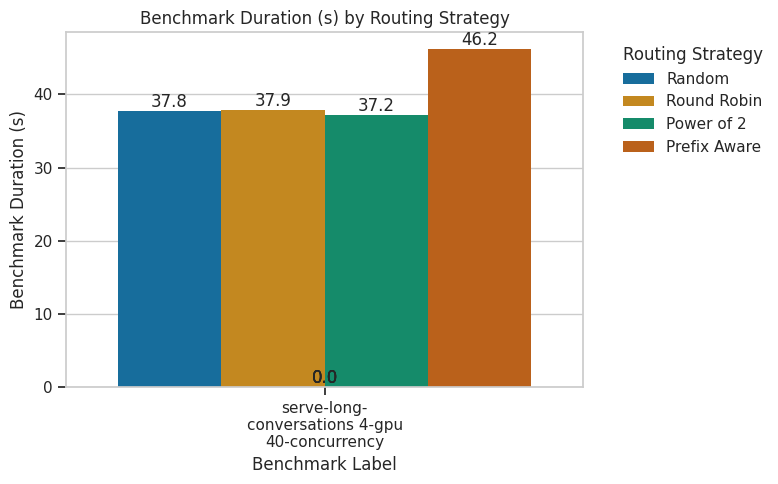

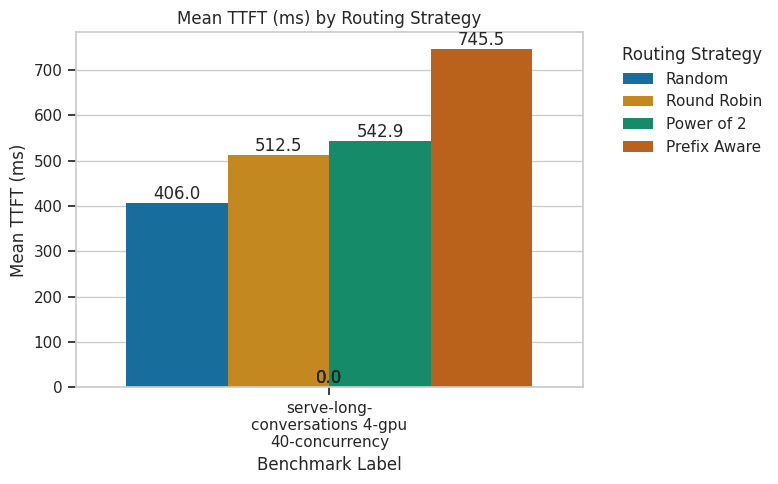

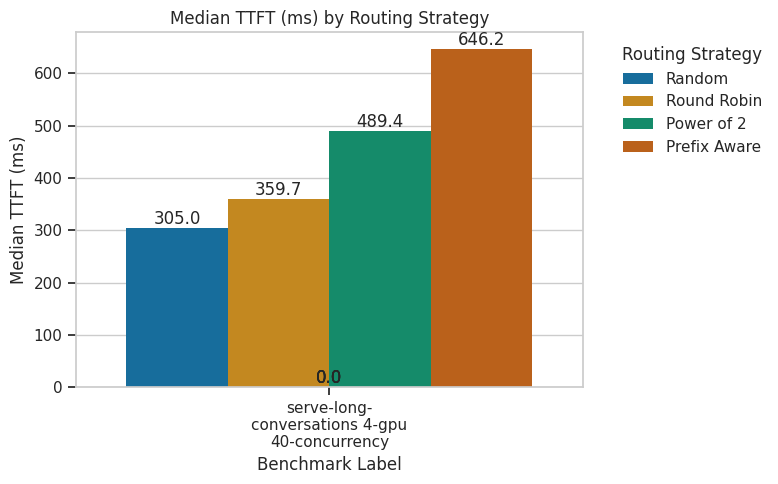

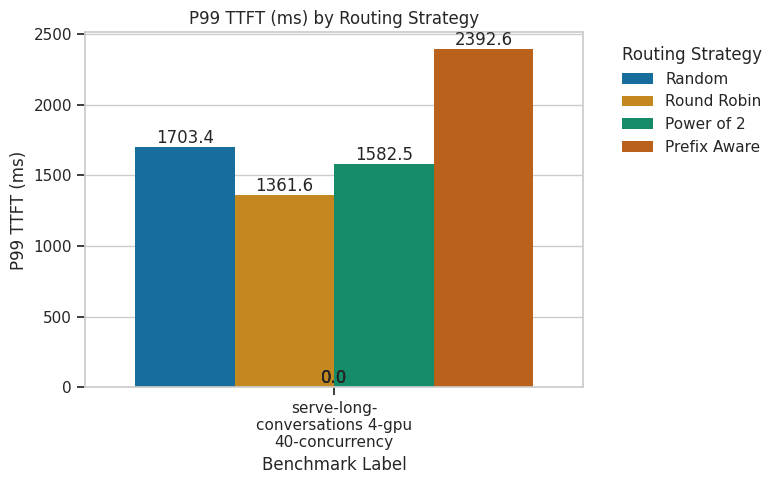

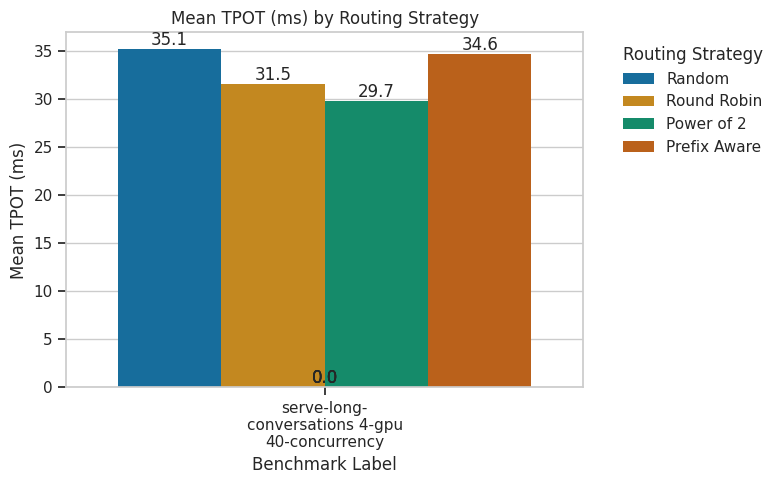

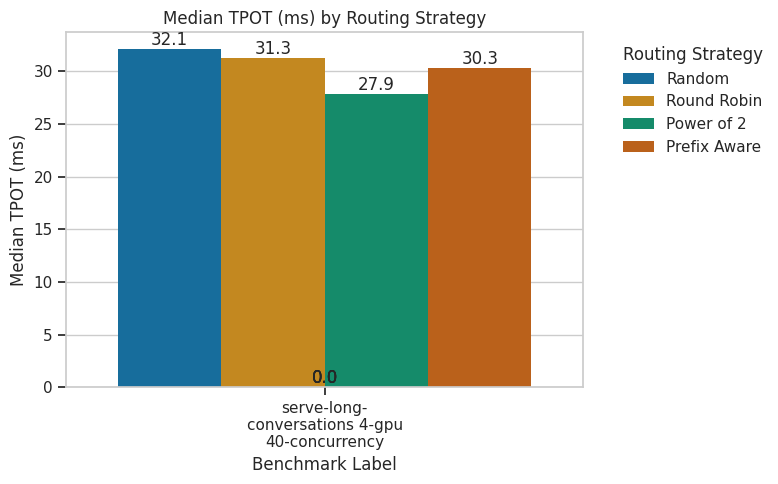

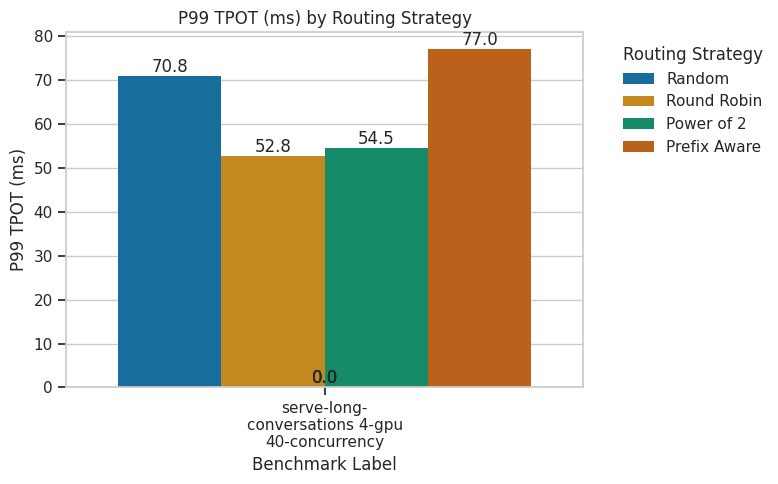

In [14]:
for metric in available_metrics:
    plot_metric_by_strategy("chosen_sweep_results.csv", metric)

In [15]:
def plot_load_distribution(json_file_path, title=None):
    """
    Plot the load distribution over time for each replica on a single chart.
    
    Args:
        json_file_path: Path to the JSON file containing load distribution data
    """
    import json
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.ticker import MaxNLocator, MultipleLocator
    
    # Load the data from the JSON file
    with open(json_file_path, 'r') as f:
        load_data = json.load(f)
    
    # Convert the data to a more usable format
    times = sorted([float(t) for t in load_data.keys() if load_data[t]])
    replicas = list(load_data[str(times[0])].keys())
    
    # Create a single figure with smaller size
    plt.figure(figsize=(12, 4))
    
    # Define colors for each replica
    colors = ['blue', 'red', 'green', 'purple']
    
    # Store all replica loads to calculate average
    all_replica_loads = []
    
    # Plot each replica's load over time on the same chart
    for i, replica_id in enumerate(replicas):
        if i >= 4:  # Only plot the first 4 replicas
            break
            
        # Extract data for this replica
        replica_loads = [load_data[str(t)].get(replica_id, 0) for t in times]
        all_replica_loads.append(replica_loads)
        
        # Plot the data with different color for each replica (more transparent)
        # Using smaller marker size (markersize=4)
        plt.plot(times, replica_loads, marker='o', markersize=2, linestyle='-', linewidth=1, 
                 color=colors[i], label=f'Replica ID: {replica_id}', alpha=0.5)
    
    # Calculate and plot the average load
    if all_replica_loads:
        avg_loads = np.mean(all_replica_loads, axis=0)
        plt.plot(times, avg_loads, marker='s', markersize=2, linestyle='-', linewidth=2, 
                 color='black', label='Average Load', zorder=10)
    
    plt.title(f'Load Distribution Across Replicas: {title}' if title is not None else 'Load Distribution Across Replicas')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Number of Requests')
    plt.grid(True)
    # Place legend outside the plot to avoid overlapping with lines
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Set y-axis to use integers only
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    # Get the current y-axis limits
    ymin, ymax = ax.get_ylim()
    
    # Set minor ticks at every integer
    ax.yaxis.set_minor_locator(MultipleLocator(1))
    
    # Set major ticks at every even integer
    ax.yaxis.set_major_locator(MultipleLocator(2))
    
    # Make sure the minor ticks (all integers) are visible
    ax.tick_params(axis='y', which='minor', length=4)
    ax.tick_params(axis='y', which='major', length=6)
    
    # Adjust layout to make room for the legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)
    plt.show()

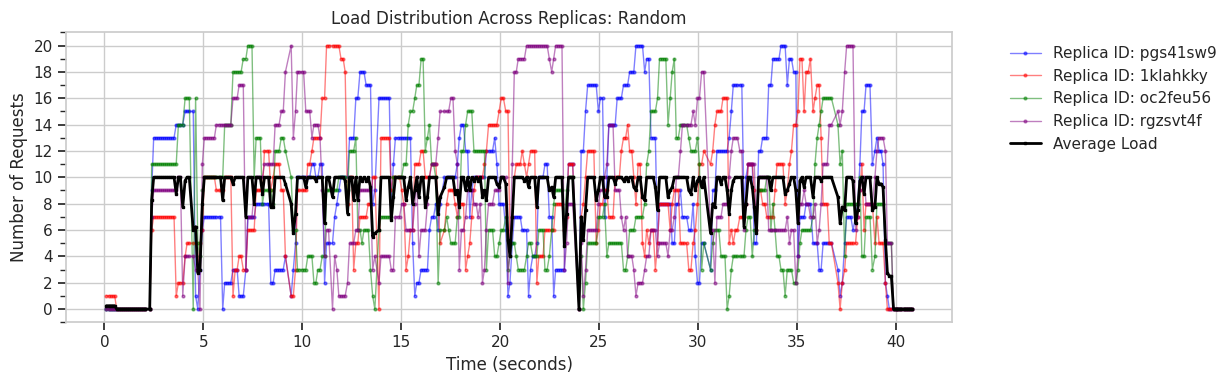

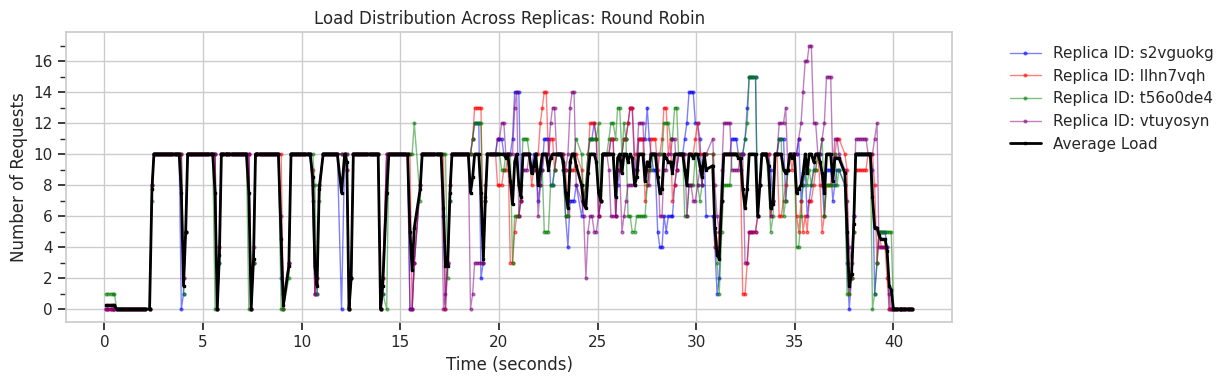

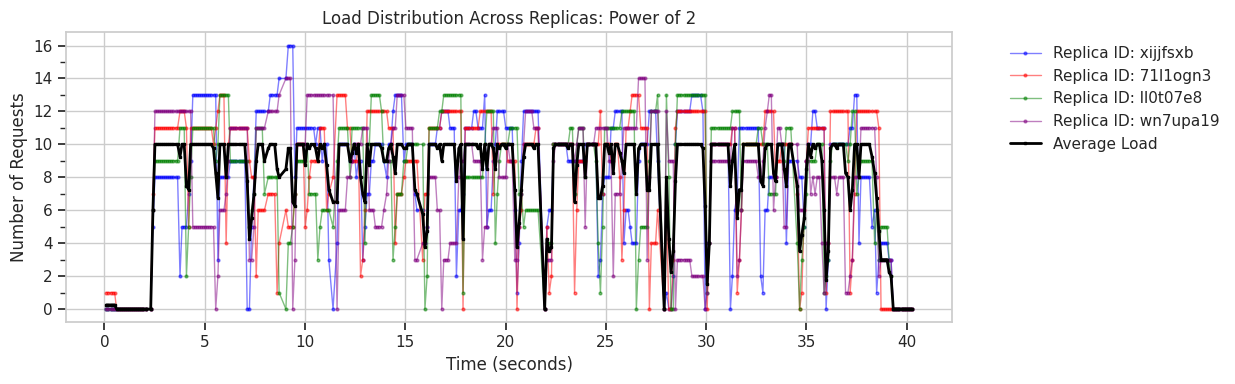

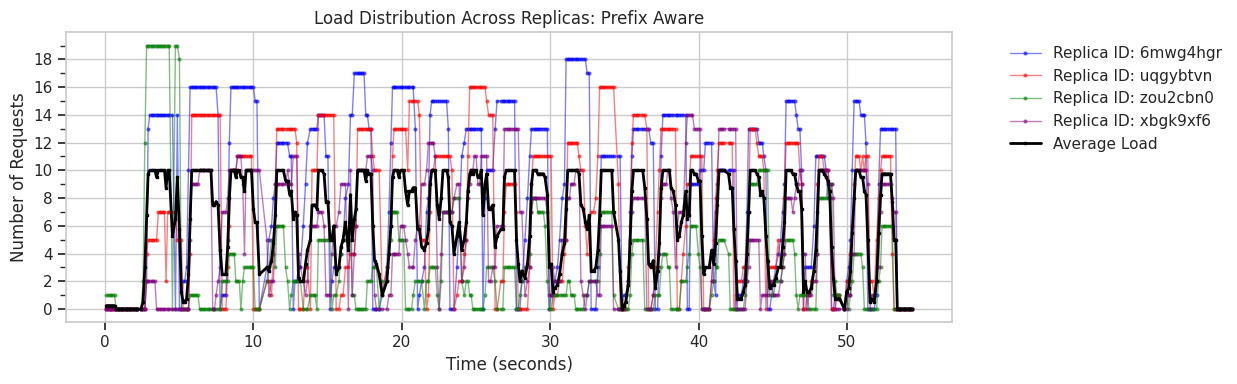

In [24]:
plot_load_distribution("/home/ray/default/work/ray/_prefix_aware_playground/benchmarking/results/load_distributions/random_1742956242.json", "Random")
plot_load_distribution("/home/ray/default/work/ray/_prefix_aware_playground/benchmarking/results/load_distributions/round_robin_1742956383.json", "Round Robin")
plot_load_distribution("/home/ray/default/work/ray/_prefix_aware_playground/benchmarking/results/load_distributions/pow_of_2_1742956520.json", "Power of 2")
plot_load_distribution("/home/ray/default/work/ray/_prefix_aware_playground/benchmarking/results/load_distributions/prefix_aware_1742964662.json", "Prefix Aware")